In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('../data/raw/train.csv')

# Faisons une copie du dataset
df_model = df.copy()
df_model['date']=pd.to_datetime(df['date'])

#création des variables temporelles
df_model['day_of_week']=df_model['date'].dt.dayofweek
df_model['month']=df_model['date'].dt.month
df_model['year']=df_model['date'].dt.year
df_model['day']=df_model['date'].dt.day 

#Ajout du numéro de la semaine
df_model['week']=df_model['date'].dt.isocalendar().week.astype(int)
df_model.head(20)

,date,store,item,sales,day_of_week,month,year,day,week
0,2013-01-01,1,1,13,1,1,2013,1,1
1,2013-01-02,1,1,11,2,1,2013,2,1
2,2013-01-03,1,1,14,3,1,2013,3,1
3,2013-01-04,1,1,13,4,1,2013,4,1
4,2013-01-05,1,1,10,5,1,2013,5,1
5,2013-01-06,1,1,12,6,1,2013,6,1
6,2013-01-07,1,1,10,0,1,2013,7,2
7,2013-01-08,1,1,9,1,1,2013,8,2
8,2013-01-09,1,1,12,2,1,2013,9,2
9,2013-01-10,1,1,9,3,1,2013,10,2


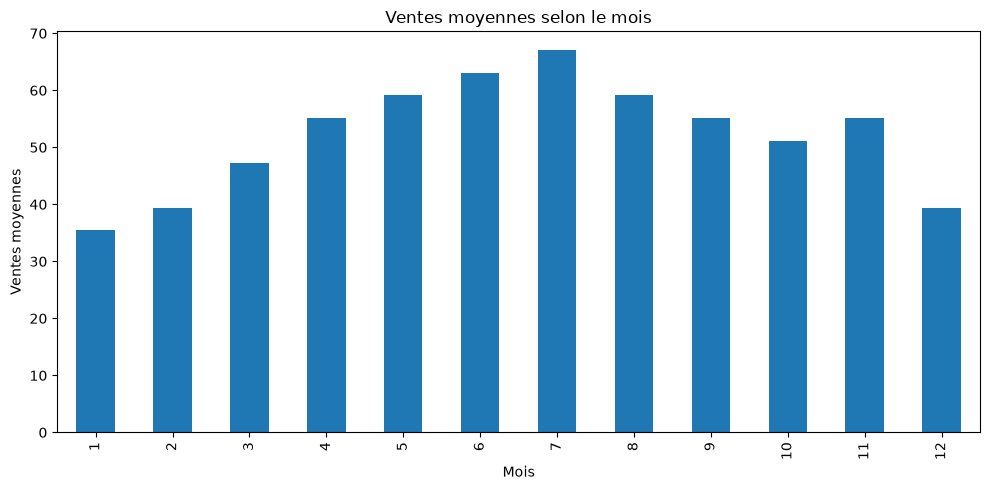

In [6]:
#Observons les ventes selon le mois
ventes_par_mois = df_model.groupby('month')['sales'].mean()
ventes_par_mois
#Visualisation
plt.figure(figsize=(10, 5))

ventes_par_mois.plot(kind="bar")

plt.title("Ventes moyennes selon le mois")
plt.xlabel("Mois")
plt.ylabel("Ventes moyennes")

plt.tight_layout()
plt.show()

In [20]:
# Nous allons créer la variable retard (lag)
# Combien d'articles ont éte vendus hier
df_model["sales_lag_1"]=(df_model.groupby(['store','item',])['sales'].shift(1))
df_model[['date','store','item','sales','sales_lag_1']].head(23)

,date,store,item,sales,sales_lag_1
0,2013-01-01,1,1,13,NaN
1,2013-01-02,1,1,11,13.0
2,2013-01-03,1,1,14,11.0
3,2013-01-04,1,1,13,14.0
4,2013-01-05,1,1,10,13.0
5,2013-01-06,1,1,12,10.0
6,2013-01-07,1,1,10,12.0
7,2013-01-08,1,1,9,10.0
8,2013-01-09,1,1,12,9.0
9,2013-01-10,1,1,9,12.0


In [21]:
df_model["sales_lag_7"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .shift(7)
)

df_model["sales_lag_14"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .shift(14)
)
df_model[['date','store','item','sales','sales_lag_1','sales_lag_7','sales_lag_14']].head(23)


,date,store,item,sales,sales_lag_1,sales_lag_7,sales_lag_14
0,2013-01-01,1,1,13,NaN,NaN,NaN
1,2013-01-02,1,1,11,13.0,NaN,NaN
2,2013-01-03,1,1,14,11.0,NaN,NaN
3,2013-01-04,1,1,13,14.0,NaN,NaN
4,2013-01-05,1,1,10,13.0,NaN,NaN
5,2013-01-06,1,1,12,10.0,NaN,NaN
6,2013-01-07,1,1,10,12.0,NaN,NaN
7,2013-01-08,1,1,9,10.0,13.0,NaN
8,2013-01-09,1,1,12,9.0,11.0,NaN
9,2013-01-10,1,1,9,12.0,14.0,NaN


In [22]:
#Nous allons créer une moyenne mobile qui represente approximativement la moyenne des 
#ventes des 7 jours précédents
df_model["rolling_mean_7"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .transform(lambda x: x.shift(1).rolling(7).mean())
)
df_model[['date','store','item','sales','sales_lag_1','sales_lag_7','sales_lag_14','rolling_mean_7']].head(23)


,date,store,item,sales,sales_lag_1,sales_lag_7,sales_lag_14,rolling_mean_7
0,2013-01-01,1,1,13,NaN,NaN,NaN,NaN
1,2013-01-02,1,1,11,13.0,NaN,NaN,NaN
2,2013-01-03,1,1,14,11.0,NaN,NaN,NaN
3,2013-01-04,1,1,13,14.0,NaN,NaN,NaN
4,2013-01-05,1,1,10,13.0,NaN,NaN,NaN
5,2013-01-06,1,1,12,10.0,NaN,NaN,NaN
6,2013-01-07,1,1,10,12.0,NaN,NaN,NaN
7,2013-01-08,1,1,9,10.0,13.0,NaN,11.857143
8,2013-01-09,1,1,12,9.0,11.0,NaN,11.285714
9,2013-01-10,1,1,9,12.0,14.0,NaN,11.428571


In [9]:
df_model.isnull().sum()

date                 0
store                0
item                 0
sales                0
day_of_week          0
month                0
year                 0
day                  0
week                 0
sales_lag_1        500
sales_lag_7       3500
sales_lag_14      7000
rolling_mean_7    3500
dtype: int64

In [10]:
df_model = df_model.dropna().copy()
df_model.isnull().sum()

date              0
store             0
item              0
sales             0
day_of_week       0
month             0
year              0
day               0
week              0
sales_lag_1       0
sales_lag_7       0
sales_lag_14      0
rolling_mean_7    0
dtype: int64

In [23]:
df_model = df_model.sort_values(['date','store','item']).reset_index(drop=True)
df_model.head()

,date,store,item,sales,day_of_week,month,year,day,week,rolling_mean_7,sales_lag_1,sales_lag_7,sales_lag_14
0,2013-01-01,1,1,13,1,1,2013,1,1,NaN,NaN,NaN,NaN
1,2013-01-01,1,2,33,1,1,2013,1,1,NaN,NaN,NaN,NaN
2,2013-01-01,1,3,15,1,1,2013,1,1,NaN,NaN,NaN,NaN
3,2013-01-01,1,4,10,1,1,2013,1,1,NaN,NaN,NaN,NaN
4,2013-01-01,1,5,11,1,1,2013,1,1,NaN,NaN,NaN,NaN


In [24]:

#Définition des variables explicatives (prédicteurs) X et la variable cible y
features = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "day_of_week",
    "week",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "rolling_mean_7"
]

X = df_model[features]
y = df_model["sales"]


print("X :",X.shape)

X : (913000, 11)


In [25]:
#séparation de entraînement et de test
#Nous allons utiliser les premières données pour entraîner le modèle et les dernières pour 
#tester ses previsions
split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

#Nous vérifions les dates de séparation
print("Dernière date entraînement :", 
        df_model.iloc[split_index - 1]["date"])


print("Première date test :", 
      df_model.iloc[split_index]["date"])



Dernière date entraînement : 2016-12-31 00:00:00
Première date test : 2016-12-31 00:00:00


In [26]:
dates = sorted(df_model["date"].unique())

split_date = dates[int(len(dates) * 0.8)]

print("Date de séparation :", split_date)


train_data = df_model[df_model["date"] < split_date].copy()
test_data = df_model[df_model["date"] >= split_date].copy()


print("Période entraînement :")
print(train_data["date"].min(), "à", train_data["date"].max())

print("\nPériode test :")
print(test_data["date"].min(), "à", test_data["date"].max())


Date de séparation : 2016-12-31 00:00:00
Période entraînement :
2013-01-01 00:00:00 à 2016-12-30 00:00:00

Période test :
2016-12-31 00:00:00 à 2017-12-31 00:00:00


In [27]:
X_train = train_data[features]
y_train = train_data["sales"]

X_test = test_data[features]
y_test = test_data["sales"]

#Vérifions qu'il n'y a pas de chevauchement temporel

print(
    "Dernière date train :",
    train_data["date"].max()
)

print(
    "Première date test :",
    test_data["date"].min()
)
print(
    "Chevauchement :",
    train_data["date"].max() >= test_data["date"].min()
)


Dernière date train : 2016-12-30 00:00:00
Première date test : 2016-12-31 00:00:00
Chevauchement : False


In [16]:
#vérifions la présence des magasins et articles print("Magasins train :", train_data["store"].nunique())
print("Magasins train :", train_data["store"].nunique())
print("Magasins test  :", test_data["store"].nunique())

print("Articles train :", train_data["item"].nunique())
print("Articles test  :", test_data["item"].nunique())

Magasins train : 10
Magasins test  : 10
Articles train : 50
Articles test  : 50


In [28]:
#modèle naif
y_pred_naive = test_data['sales_lag_1']

#Calcul des erreurs
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_naive = mean_absolute_error(y_test, y_pred_naive)

rmse_naive = np.sqrt(
    mean_squared_error(y_test, y_pred_naive)
)

r2_naive = r2_score(y_test, y_pred_naive)

print("MAE :", mae_naive)
print("RMSE :", rmse_naive)
print("R² :", r2_naive)

MAE : 11.236142076502732
RMSE : 15.377803533991928
R² : 0.7622560610322318


In [29]:
#Modèle : Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

#création du modèle
model_rf = RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)

#Entraînement du modèle
model_rf.fit(X_train,y_train)

#Faisons les prédictions
y_pred_rf = model_rf.predict(X_test)

#Evaluons le modèle
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R² :", r2_rf)


Random Forest
MAE : 6.539575901639345
RMSE : 8.50667027680988
R² : 0.9272488208106994


In [26]:
print('Voir quelques prédictions')
comparaison = pd.DataFrame({
    "date": test_data["date"].values,
    "store": test_data["store"].values,
    "item": test_data["item"].values,
    "demande_reelle": y_test.values,
    "prediction": y_pred_rf
})

comparaison.head(20)

Voir quelques prédictions


,date,store,item,demande_reelle,prediction
0,2017-01-03,1,1,10,17.50
1,2017-01-03,1,2,33,40.28
2,2017-01-03,1,3,20,29.77
3,2017-01-03,1,4,12,17.95
4,2017-01-03,1,5,13,17.49
5,2017-01-03,1,6,31,40.32
6,2017-01-03,1,7,31,42.46
7,2017-01-03,1,8,45,52.59
8,2017-01-03,1,9,26,33.10
9,2017-01-03,1,10,53,54.30


In [27]:
#Modèle : Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_test)
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting")
print("MAE :", mae_gb)
print("RMSE :", rmse_gb)
print("R² :", r2_gb)



Gradient Boosting
MAE : 6.5420901774551385
RMSE : 8.523036665445524
R² : 0.927106737187643


In [28]:

print('Comparaison des modèles')
resultats = pd.DataFrame({
    "Modèle": [
        "Baseline",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        mae_naive,
        mae_rf,
        mae_gb
    ],
    "RMSE": [
        rmse_naive,
        rmse_rf,
        rmse_gb
    ],
    "R²": [
        r2_naive,
        r2_rf,
        r2_gb
    ]
})

resultats


Comparaison des modèles


,Modèle,MAE,RMSE,R²
0,Baseline,11.241642,15.389949,0.762331
1,Random Forest,6.544355,8.509306,0.927341
2,Gradient Boosting,6.542090,8.523037,0.927107


Visualisation des modèles : réelle vs prédiction
Random Forest


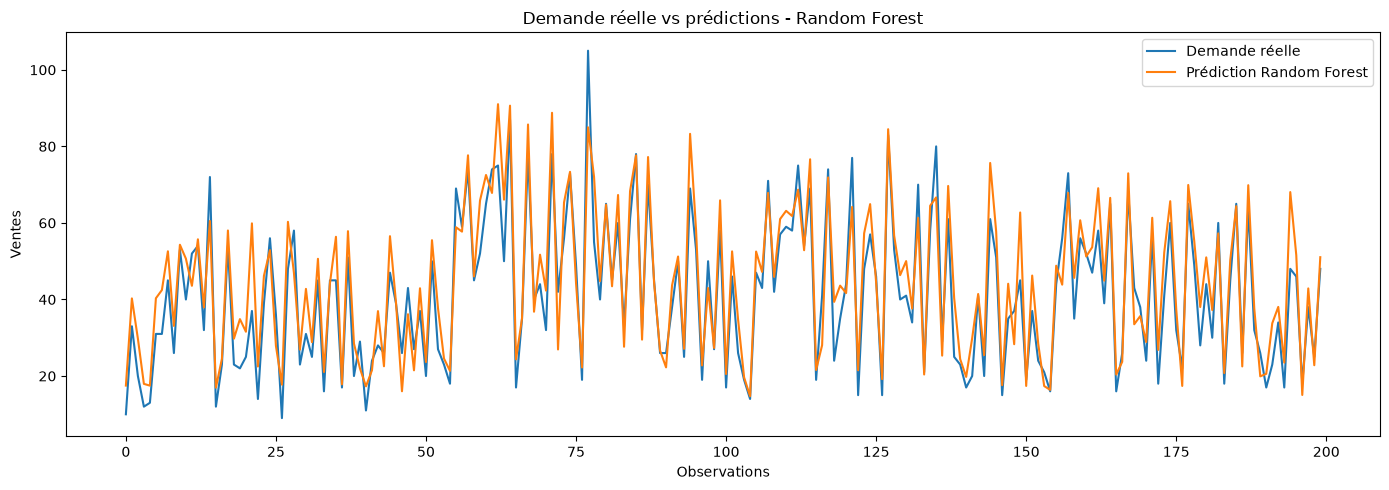

Gradient Boosting


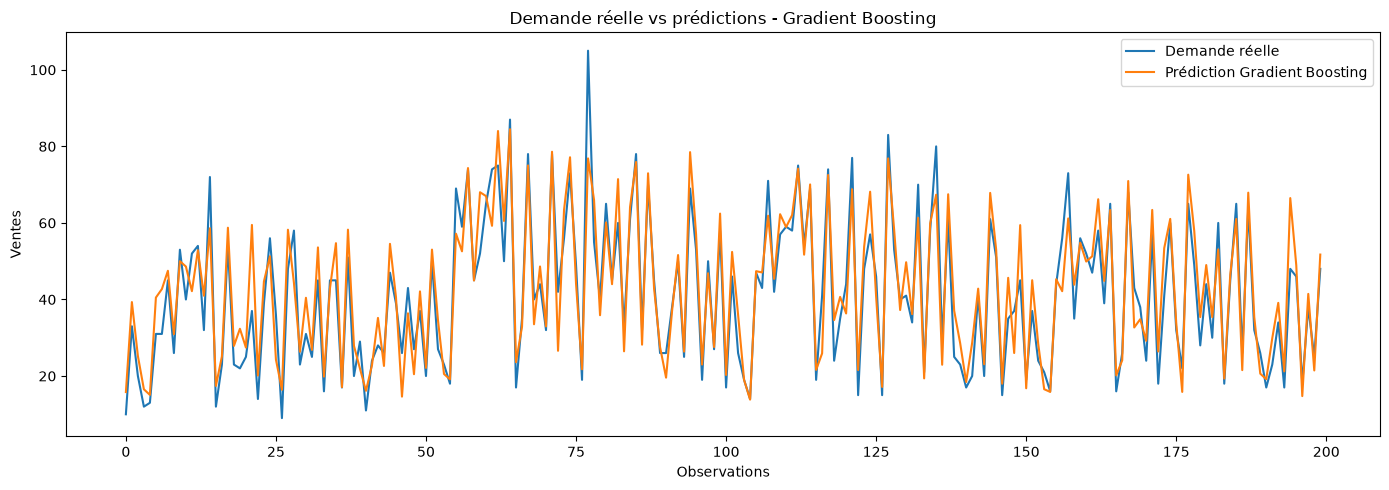

In [29]:
print('Visualisation des modèles : réelle vs prédiction')

print('Random Forest')
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.iloc[:200].values,
    label="Demande réelle"
)

plt.plot(
    y_pred_rf[:200],
    label="Prédiction Random Forest"
)

plt.title("Demande réelle vs prédictions - Random Forest")
plt.xlabel("Observations")
plt.ylabel("Ventes")
plt.legend()

plt.tight_layout()
plt.show()


print("Gradient Boosting")
plt.figure(figsize=(14, 5))

plt.plot(
    y_test.iloc[:200].values,
    label="Demande réelle"
)

plt.plot(
    y_pred_gb[:200],
    label="Prédiction Gradient Boosting"
)

plt.title("Demande réelle vs prédictions - Gradient Boosting")
plt.xlabel("Observations")
plt.ylabel("Ventes")
plt.legend()

plt.tight_layout()
plt.show()


In [30]:
#Amélioration des variables temporelles 
#Ajout des moyennes mobiles sur 7,14 et 30 jours toujours par magasin et par article
df_model["rolling_mean_14"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .transform(lambda x: x.shift(1).rolling(14).mean())
)

df_model["rolling_mean_30"] = (
    df_model
    .groupby(["store", "item"])["sales"]
    .transform(lambda x: x.shift(1).rolling(30).mean())
)


#Ajout des variales à features
features = [
    "store",
    "item",
    "year",
    "month",
    "day",
    "day_of_week",
    "week",
    "sales_lag_1",
    "sales_lag_7",
    "sales_lag_14",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30"
]

#suppression des nouvelles valeures manquantes
df_model = df_model.dropna().copy()


In [31]:
#Nous allons refaire la séparation temporelle
dates = sorted(df_model["date"].unique())

split_date = dates[int(len(dates) * 0.8)]

train_data = df_model[df_model["date"] < split_date].copy()
test_data = df_model[df_model["date"] >= split_date].copy()

#On prépare X et y
X_train = train_data[features]
y_train = train_data["sales"]

X_test = test_data[features]
y_test = test_data["sales"]

In [32]:

print('Random Forest amélioré')
model_rf_2 = RandomForestRegressor(
    n_estimators=100,
    random_state=15,
    n_jobs=-1,max_depth=15,min_samples_leaf=2
)

model_rf_2.fit(X_train, y_train)
y_pred_rf_2 = model_rf_2.predict(X_test)
mae_rf_2 = mean_absolute_error(y_test, y_pred_rf_2)

rmse_rf_2 = np.sqrt(
    mean_squared_error(y_test, y_pred_rf_2)
)

r2_rf_2 = r2_score(y_test, y_pred_rf_2)

print("Random Forest amélioré")
print("MAE :", mae_rf_2)
print("RMSE :", rmse_rf_2)
print("R² :", r2_rf_2)

Random Forest amélioré
Random Forest amélioré
MAE : 6.275014056046657
RMSE : 8.177379108267527
R² : 0.9330176680881286


In [34]:
print('Gradient Boosting amélioré')
model_gb_2 = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model_gb_2.fit(X_train, y_train)

y_pred_gb_2 = model_gb_2.predict(X_test)
mae_gb_2 = mean_absolute_error(y_test, y_pred_gb_2)

rmse_gb_2 = np.sqrt(
    mean_squared_error(y_test, y_pred_gb_2)
) 

r2_gb_2 = r2_score(y_test, y_pred_gb_2)

print("Gradient Boosting amélioré")
print("MAE :", mae_gb_2)
print("RMSE :", rmse_gb_2)
print("R² :", r2_gb_2)


Gradient Boosting amélioré
Gradient Boosting amélioré
MAE : 6.501924766714601
RMSE : 8.480925317467841
R² : 0.9281441731028159


In [36]:
resultats_final = pd.DataFrame({
    "Modèle": [
        "Baseline",
        "Random Forest",
        "Random Forest amélioré",
        "Gradient Boosting",
        "Gradient Boosting amélioré"
    ],
    "MAE": [
        mae_naive,
        mae_rf,
        mae_rf_2,
        mae_gb,
        mae_gb_2
    ],
    "RMSE": [
        rmse_naive,
        rmse_rf,
        rmse_rf_2,
        rmse_gb,
        rmse_gb_2
    ],
    "R²": [
        r2_naive,
        r2_rf,
        r2_rf_2,
        r2_gb,
        r2_gb_2
    ]
})

resultats_final

,Modèle,MAE,RMSE,R²
0,Baseline,11.241642,15.389949,0.762331
1,Random Forest,6.544355,8.509306,0.927341
2,Random Forest amélioré,6.327150,8.233129,0.932282
3,Gradient Boosting,6.542090,8.523037,0.927107
4,Gradient Boosting amélioré,6.501925,8.480925,0.928144


In [33]:



from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print('Le modèle retenu est Random Forest')
y_pred_final = model_rf_2.predict(X_test)
#Calcul des métriques finales
mae_final = mean_absolute_error(y_test, y_pred_final)

rmse_final = np.sqrt(
    mean_squared_error(y_test, y_pred_final)
)

r2_final = r2_score(y_test, y_pred_final)

print(" MODÈLE FINAL")
print("Modèle : Random Forest amélioré")
print("MAE :", mae_final)
print("RMSE :", rmse_final)
print("R² :", r2_final)

Le modèle retenu est Random Forest
 MODÈLE FINAL
Modèle : Random Forest amélioré
MAE : 6.275014056046657
RMSE : 8.177379108267527
R² : 0.9330176680881286


In [37]:
#comparaison demande réelle et prediction
import pandas as pd

comparaison_finale = pd.DataFrame({
    "date": test_data["date"].values,
    "store": test_data["store"].values,
    "item": test_data["item"].values,
    "demande_reelle": y_test.values,
    "prediction": y_pred_final
})

comparaison_finale.head(20)

,date,store,item,demande_reelle,prediction
0,2017-01-03,1,1,10,17.50
1,2017-01-03,1,2,33,40.28
2,2017-01-03,1,3,20,29.77
3,2017-01-03,1,4,12,17.95
4,2017-01-03,1,5,13,17.49
5,2017-01-03,1,6,31,40.32
6,2017-01-03,1,7,31,42.46
7,2017-01-03,1,8,45,52.59
8,2017-01-03,1,9,26,33.10
9,2017-01-03,1,10,53,54.30


In [35]:
#calcul des erreurs
comparaison_finale = pd.DataFrame({
    "date": test_data["date"].values,
    "store": test_data["store"].values,
    "item": test_data["item"].values,
    "demande_reelle": y_test.values,
    "prediction": y_pred_final
})

comparaison_finale.head(20)


,date,store,item,demande_reelle,prediction
0,2017-01-03,1,1,10,17.50
1,2017-01-03,1,2,33,40.28
2,2017-01-03,1,3,20,29.77
3,2017-01-03,1,4,12,17.95
4,2017-01-03,1,5,13,17.49
5,2017-01-03,1,6,31,40.32
6,2017-01-03,1,7,31,42.46
7,2017-01-03,1,8,45,52.59
8,2017-01-03,1,9,26,33.10
9,2017-01-03,1,10,53,54.30


In [58]:
comparaison_finale['erreur']= (comparaison_finale['demande_reelle']-comparaison_finale['prediction'])
comparaison_finale['erreur_absolue']=comparaison_finale['erreur'].abs()

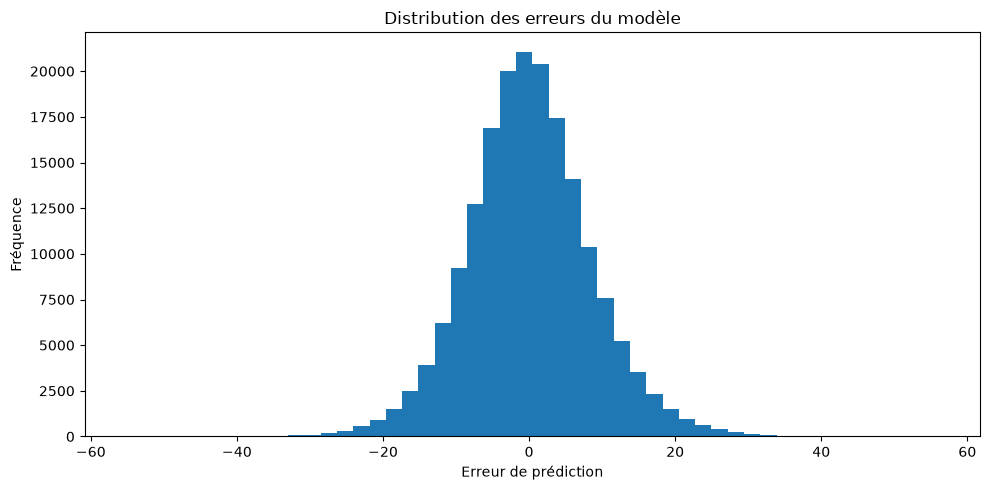

In [48]:
#Distribution des erreurs du modèle

plt.figure(figsize=(10, 5))

plt.hist(comparaison_finale["erreur"], bins=50)

plt.title("Distribution des erreurs du modèle")
plt.xlabel("Erreur de prédiction")
plt.ylabel("Fréquence")

plt.tight_layout()
plt.show()
# cette visualisation est importante pour l'analyse du modèle:on cherche à comprendre si les erreurs sont
#plutôt petites et centrées autour de 0


In [56]:
print(len(features))
print(len(model_rf_2.feature_importances_))

13
13


Importance des variables du modèle final


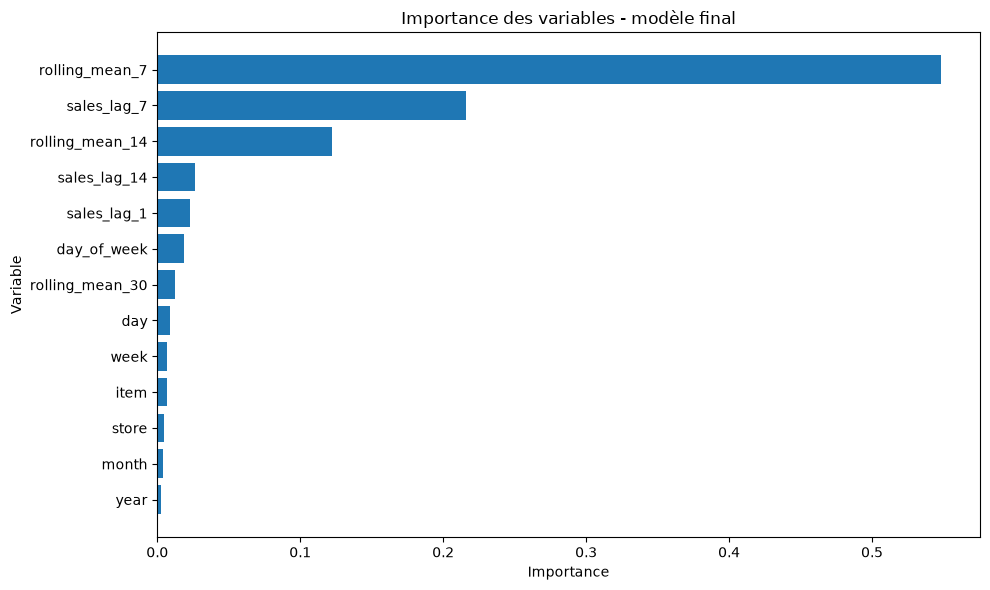

In [57]:
print('Importance des variables du modèle final')
importance_finale = pd.DataFrame({
    "Variable": features,
    "Importance": model_rf_2.feature_importances_
})

importance_finale = importance_finale.sort_values(
    "Importance",
    ascending=False
)

importance_finale
plt.figure(figsize=(10, 6))

plt.barh(
    importance_finale["Variable"],
    importance_finale["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Importance des variables - modèle final")
plt.xlabel("Importance")
plt.ylabel("Variable")

plt.tight_layout()
plt.show()
#c'est l'idée d'interprétation du modèle : nous cherchons à comprendre quelles informations
#ont contribué à la prédiction

In [59]:
print('Performance par magasin')
comparaison_finale.groupby("store")["erreur_absolue"].mean().sort_values()

print('Performance par article')
comparaison_finale.groupby("item")["erreur_absolue"].mean().sort_values()

Performance par magasin
Performance par article


item
5     3.864248
1     4.232201
27    4.280581
47    4.301782
4     4.363689
41    4.407187
16    4.623975
34    4.702551
37    4.937848
49    4.978468
40    4.983105
44    5.020446
23    5.150986
17    5.313168
3     5.589231
42    5.637937
19    5.729623
21    5.772044
30    5.986116
32    6.105088
20    6.183956
39    6.305523
26    6.347749
48    6.572088
9     6.678793
43    6.771121
46    6.967135
6     7.032848
7     7.087573
31    7.112375
2     7.114066
14    7.188694
50    7.423008
35    7.474711
33    7.563766
11    7.569926
24    7.640022
12    7.781636
29    7.799025
10    7.979322
36    8.103350
8     8.172149
25    8.277705
45    8.278614
22    8.280579
38    8.487129
13    8.656386
18    8.696157
15    8.778545
28    8.913507
Name: erreur_absolue, dtype: float64

In [36]:
#Nous allons maintenant sauvegarder le modèle
import joblib

joblib.dump(
    model_rf_2,
    "../models/modele_demande_random_forest.joblib",compress=3
)
#vérification 
import os

print(
    os.path.exists(
        "../models/modele_demande_random_forest.joblib"
    )
)

True


In [37]:
print('sauvegarde des variables ')
import json

metadata = {
    "features": features,
    "target": "sales",
    "model": "Random Forest Regressor",
    "lags": [1, 7, 14],
    "rolling_windows": [7, 14, 30]
}

with open("../models/metadata.json", "w", encoding="utf-8") as fichier:
    json.dump(metadata, fichier, indent=4)

sauvegarde des variables 


In [40]:
import joblib
joblib.dump(model_rf_2, '../models/modele_demande_random_forest.joblib', compress=0)
print('Modèle chargé avec succès')

Modèle chargé avec succès


In [41]:
prediction = model_rf_2.predict(X_test)

In [43]:
display(prediction)

array([15.63849321, 46.57558269, 27.749415  , ..., 55.18055382,
       30.85621595, 72.60055905], shape=(180000,))